<a href="https://colab.research.google.com/github/BinnBingus/HackatonSummitUMC/blob/main/HackatonCi%C3%AAnciaDeDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Limpeza e Peparação de Dados**


---



**Importações Nescessárias**

In [ ]:
# Pandas - Blibioteca de manipula e análisa os dados de forma estruturada.
# Numpy - Operações matemáticas avançadas e suas manipulações.
import pandas as pd
import numpy as np

# matplotlib.pylot - Criação de gráficos gerais.
# seaborn - complemetnos do Matplotlib para vizulização de estatisticas.
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_lib - Separador de dados em conjuntos de treinamento e teste.
# LinearRegression - Modelo de regressão Linear entre váriaveis independentes e que seja previstas.
# mean_squares_error - Medidas de erros das previsões , dando maior peso aos erros grandes.
# mean_absolute_error - Calcula média de difrenças absoluta entre valores reais e previstos.
# r2_score - Avalia quandoa variação da váriavel dependente é mostrada no modelo.
# StandardScaler - Traformação de váriaveis numéricas de zero e desvio padrão próximo de um.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

*Justificativa das importações*

A estrutura inicial do código foi organizada para dar suporte a um processo de análise de dados e modelagem preditiva. A lógica consiste em preparar os recursos necessários para trabalhar com os dados, explorar suas características, realizar o treinamento de um modelo de regressão linear e avaliar a qualidade das previsões obtidas. Essa organização permite que o desenvolvimento siga uma sequência coerente, desde o tratamento das informações até a análise dos resultados, contribuindo para um processo mais estruturado, interpretável e confiável.

---



**Carregando os dados**

*Preparos antes do Carregamento de Dados*

A estrutura de código abaixo, mostra funções que vão ser necessárias para começar a tratar dos dados e realizar a sua limpeza, criamos funções onde elas se repetiram nas tabelas para evitar o excesso de linhas desnecessárias e assim otimizando e tento uma melhor visibilidade do código.

In [ ]:
# Função para Limpar e Tratar Colunas
def LimparConverter(Numero):
    if pd.isna(Numero):
        return Numero

    val_str = str(Numero).strip()

    if val_str in ['-', '']:
        return None

    # Formatação Americana para Brasileira dos Numeros
    val_str = val_str.replace('.', '').replace(',', '.')

    try:
        return float(val_str)
    except ValueError:
        return Numero

# Função de Verificar e Forçar Coluna
def RemoverNaN(Ano):
  for col in Ano.select_dtypes(include=['object']).columns:
    col_convertida = Ano[col].apply(LimparConverter)
    # Substituído 'ignore' por 'coerce' para evitar erros futuros e tratar vazamentos de string
    col_numerica = pd.to_numeric(col_convertida, errors='coerce')

    if col_numerica.notnull().sum() > 0:
        Ano[col] = col_numerica
    else:
        Ano[col] = col_convertida

def converter_para_float(coluna):
    if coluna.dtype == 'object':
        coluna = coluna.astype(str).str.replace('%', '', regex=False)
        coluna = coluna.str.replace(',', '.', regex=False).str.strip()
    return pd.to_numeric(coluna, errors='coerce')

# **Análise Exploratória e Estatística Descretiva**



---



**Extração e Cálculo da Eleição de 1932**

Este trecho de código é o responsável por carregar e limpar os dados da eleição de 1932. Ele padroniza os nomes das colunas do arquivo para evitar erros de leitura e cria uma função de segurança que garante a extração dos votos numéricos sem quebrar o programa. A partir disso, o código calcula matematicamente a proporção de votos do candidato republicano tanto na pesquisa da revista quanto no resultado real das urnas, descartando as linhas vazias no final para deixar a base de dados perfeitamente estruturada para a inteligência artificial.

In [ ]:
df_1932 = pd.read_csv('/content/LitDigestFull(1932).csv', encoding='cp1252', sep=';')

# Rodar sua função de limpeza existente
RemoverNaN(df_1932)

# Normalizar os nomes das colunas para maiúsculas e remover espaços extras
df_1932.columns = [str(col).strip().upper() for col in df_1932.columns]

# Se houver colunas com o mesmo nome, o pandas pode criar duplicatas. Vamos remover duplicatas de colunas mantendo a primeira:
df_1932 = df_1932.loc[:, ~df_1932.columns.duplicated()]

# Função auxiliar totalmente blindada
def obter_serie_segura(df, nome_coluna):
    if nome_coluna in df.columns:
        serie = df[nome_coluna]
        # Se por acaso ainda for um DataFrame (2D), pega apenas a primeira coluna dele
        if isinstance(serie, pd.DataFrame):
            serie = serie.iloc[:, 0]
        return pd.to_numeric(serie, errors='coerce').fillna(0)
    else:
        print(f"Aviso: Coluna '{nome_coluna}' não encontrada. Usando zeros.")
        return pd.Series(0.0, index=df.index)

# 1. Proporção da Pesquisa Literary Digest (LD) para Hoover e Roosevelt
votos_hoover_ld_32 = obter_serie_segura(df_1932, 'HOOVER')
votos_roose_ld_32 = obter_serie_segura(df_1932, 'ROOSEVELT')

total_ld = votos_hoover_ld_32 + votos_roose_ld_32
# Evitar divisão por zero substituindo 0 por NaN temporariamente
total_ld = total_ld.replace(0, pd.NA)

df_1932['prop_republicana_LD_1932'] = votos_hoover_ld_32 / total_ld

# 2. Proporção Real nas Urnas
if 'HOOVER_REAL' in df_1932.columns and 'TOTAL_VOTES' in df_1932.columns:
    votos_hoover_real = obter_serie_segura(df_1932, 'HOOVER_REAL')
    total_votes_32 = obter_serie_segura(df_1932, 'TOTAL_VOTES')
    df_1932['prop_republicana_real_1932'] = votos_hoover_real / total_votes_32.replace(0, pd.NA)
else:
    # --- AQUI ESTÁ A CORREÇÃO ---
    # Verifica se a coluna '%.1' existe (padrão do Pandas para a 2ª coluna duplicada de '%')
    if '%.1' in df_1932.columns:
        serie_real = obter_serie_segura(df_1932, '%.1')
    else:
        # Caso utilize outra nomenclatura, busca as colunas de %
        colunas_candidatas = [c for c in df_1932.columns if '%' in c or 'PCT' in c]

        # Pega a SEGUNDA coluna (índice 1 - Hoover), e não a primeira (índice 0 - Roosevelt)
        if len(colunas_candidatas) > 1:
            coluna_porcentagem = colunas_candidatas[1]
        elif colunas_candidatas:
            coluna_porcentagem = colunas_candidatas[0]
        else:
            coluna_porcentagem = df_1932.columns[0]

        serie_real = obter_serie_segura(df_1932, coluna_porcentagem)

    df_1932['prop_republicana_real_1932'] = serie_real / 100.0

# Limpar linhas nulas e testar
df_1932_limpo = df_1932.dropna(subset=['prop_republicana_LD_1932', 'prop_republicana_real_1932']).copy()
print(df_1932_limpo[['prop_republicana_LD_1932', 'prop_republicana_real_1932']].head(10))

   prop_republicana_LD_1932  prop_republicana_real_1932
1                  0.174845                      0.3053
2                  0.343934                      0.1291
3                  0.186186                      0.3739
4                  0.354773                      0.4143
5                  0.455169                      0.4854
6                  0.610546                      0.5055
7                   0.48357                      0.2504
8                  0.437542                      0.0777
9                  0.282667                      0.3827
10                 0.131517                      0.4204


**Extração e Cálculo para a Eleição de 1936**



In [ ]:
# Carregando os dados de 1936
df_1936 = pd.read_csv('/content/LitDigestFull(1936).csv', encoding='cp1252', sep=';')

# Rodar a função de limpeza existente (mesma usada em 1932)
RemoverNaN(df_1936)

# Normalizar os nomes das colunas para maiúsculas e remover espaços extras
df_1936.columns = [str(col).strip().upper() for col in df_1936.columns]

# Remover duplicatas de colunas mantendo a primeira
df_1936 = df_1936.loc[:, ~df_1936.columns.duplicated()]

print("Dataset de 1936 carregado com sucesso! Colunas disponíveis:")
print(df_1936.columns.tolist())

Dataset de 1936 carregado com sucesso! Colunas disponíveis:
['UNNAMED: 0', 'UNNAMED: 1', 'LANDON  (R)', 'HOW DID THEY VOTE IN 1932?', 'UNNAMED: 4', 'UNNAMED: 5', 'UNNAMED: 6', 'UNNAMED: 7', 'UNNAMED: 8', 'UNNAMED: 9', 'ROOSEVELT  (D)', 'HOW DID THEY VOTE IN 1932?.1', 'UNNAMED: 12', 'UNNAMED: 13', 'UNNAMED: 14', 'UNNAMED: 15', 'UNNAMED: 16', 'UNNAMED: 17', 'LEMKE (UNION)', 'HOW DID THEY VOTE IN 1932?.2', 'UNNAMED: 20', 'UNNAMED: 21', 'UNNAMED: 22', 'UNNAMED: 23', 'UNNAMED: 24', 'UNNAMED: 25', 'MINOR CANDIDATES', 'UNNAMED: 27', 'UNNAMED: 28', 'UNNAMED: 29', 'UNNAMED: 30', 'UNNAMED: 31', 'GRAND TOTAL VOTES', 'UNNAMED: 33', 'STATE - 1936', 'ELECTORAL VOTES', 'ROOSEVELT', '%', 'ELECTORAL VOTES.1', 'LANDON', '%.1', 'ELECTORAL VOTES.2', 'LEMKE (UNION).1', '%.2', 'ELECTORAL VOTES.3', 'THOMAS (SOC.)', '%.3', 'ELECTORAL VOTES.4', 'OTHER', '%.4', 'ELECTORAL VOTES.5', 'MARGIN', '%.5', 'TOTAL VOTES', 'STATE', 'UNNAMED: 55']


In [ ]:
# Garantir conversão para número (float) das intenções de voto da Pesquisa LD
votos_landon_ld_36 = pd.to_numeric(df_1936['LANDON  (R)'], errors='coerce').fillna(0)
votos_roose_ld_36 = pd.to_numeric(df_1936['ROOSEVELT  (D)'], errors='coerce').fillna(0)

df_1936['prop_republicana_LD_1936'] = votos_landon_ld_36 / (votos_landon_ld_36 + votos_roose_ld_36)

# Resultado Real nas Urnas em 1936 (% de Landon)
if '%.1' in df_1936.columns:
    df_1936['Pct_Real_Rep_1936'] = pd.to_numeric(df_1936['%.1'], errors='coerce') / 100.0
elif 'LANDON' in df_1936.columns and 'TOTAL VOTES' in df_1936.columns:
    votos_landon_real = pd.to_numeric(df_1936['LANDON'], errors='coerce')
    total_votes_36 = pd.to_numeric(df_1936['TOTAL VOTES'], errors='coerce')
    df_1936['Pct_Real_Rep_1936'] = votos_landon_real / total_votes_36

**Limpeza para Análise e Modelagem**

In [ ]:
df_1932_limpo = df_1932.dropna(subset=['prop_republicana_LD_1932', 'prop_republicana_real_1932']).copy()
df_1936_limpo = df_1936.dropna(subset=['prop_republicana_LD_1936', 'Pct_Real_Rep_1936']).copy()

# Cálculo do Erro / Viés (Pesquisa - Real)
df_1932_limpo['vies_1932'] = df_1932_limpo['prop_republicana_LD_1932'] - df_1932_limpo['prop_republicana_real_1932']
df_1936_limpo['vies_1936'] = df_1936_limpo['prop_republicana_LD_1936'] - df_1936_limpo['Pct_Real_Rep_1936']

**Ajuste da Regressão Linear (Modelo Preditivo Treinado em 1932)**

In [ ]:
X_treino_1932 = df_1932_limpo[['prop_republicana_LD_1932']]
y_treino_1932 = df_1932_limpo['prop_republicana_real_1932']

modelo_reg = LinearRegression()
modelo_reg.fit(X_treino_1932, y_treino_1932)


LinearRegression()

****

**Exibição da Estatística Descritiva no Console**

In [ ]:
print("-=-=-=-=-=-=-=-=-= RESUMO DA ESTATÍSTICA DESCRITIVA E DIAGNÓSTICO DE VIÉS -=-=-=-=-=-=-==-=-=")


print("\n ELEIÇÃO DE 1932 (TREINO)")
stats_32 = df_1932_limpo[['prop_republicana_LD_1932', 'prop_republicana_real_1932', 'vies_1932']].describe().T
stats_32.rename(index={
    'prop_republicana_LD_1932': 'Pesquisa LD (1932)',
    'prop_republicana_real_1932': 'Resultado Real (1932)',
    'vies_1932': 'Viés / Erro (1932)'
}, inplace=True)
display(stats_32[['mean', 'std', 'min', '50%', 'max']].round(4))

print("\n ELEIÇÃO DE 1936 (TESTE / VALIDAÇÃO)")
stats_36 = df_1936_limpo[['prop_republicana_LD_1936', 'Pct_Real_Rep_1936', 'vies_1936']].describe().T
stats_36.rename(index={
    'prop_republicana_LD_1936': 'Pesquisa LD (1936)',
    'Pct_Real_Rep_1936': 'Resultado Real (1936)',
    'vies_1936': 'Viés / Erro (1936)'
}, inplace=True)
display(stats_36[['mean', 'std', 'min', '50%', 'max']].round(4))

vies_medio_32 = df_1932_limpo['vies_1932'].mean() * 100
vies_medio_36 = df_1936_limpo['vies_1936'].mean() * 100

print("\n DIAGNÓSTICO FINAL DO VIÉS DA LITERARY DIGEST: \n")
print(f"• Sobrestimação Média do Partido Republicano em 1932: {vies_medio_32:+.2f}% p.p.")
print(f"• Sobrestimação Média do Partido Republicano em 1936: {vies_medio_36:+.2f}% p.p.")
print(f"• Inclinacao da Regressão (1932): {modelo_reg.coef_[0]:.4f}")
print(f"• Intercepto da Regressão (1932): {modelo_reg.intercept_:.4f}")

-=-=-=-=-=-=-=-=-= RESUMO DA ESTATÍSTICA DESCRITIVA E DIAGNÓSTICO DE VIÉS -=-=-=-=-=-=-==-=-=

 ELEIÇÃO DE 1932 (TREINO)


,mean,std,min,50%,max
Resultado Real (1932),0.3342,0.1519,0.0,0.3629,0.5766



 ELEIÇÃO DE 1936 (TESTE / VALIDAÇÃO)


,mean,std,min,50%,max
Pesquisa LD (1936),0.522,0.1611,0.1224,0.5621,0.7711
Resultado Real (1936),0.334,0.1158,0.0143,0.3679,0.5639
Viés / Erro (1936),0.188,0.1984,-0.2756,0.1930,0.7345



 DIAGNÓSTICO FINAL DO VIÉS DA LITERARY DIGEST: 

• Sobrestimação Média do Partido Republicano em 1932: +4.13% p.p.
• Sobrestimação Média do Partido Republicano em 1936: +18.80% p.p.
• Inclinacao da Regressão (1932): -0.1660
• Intercepto da Regressão (1932): 0.3966


# **Diagnóstico de Viés**



---



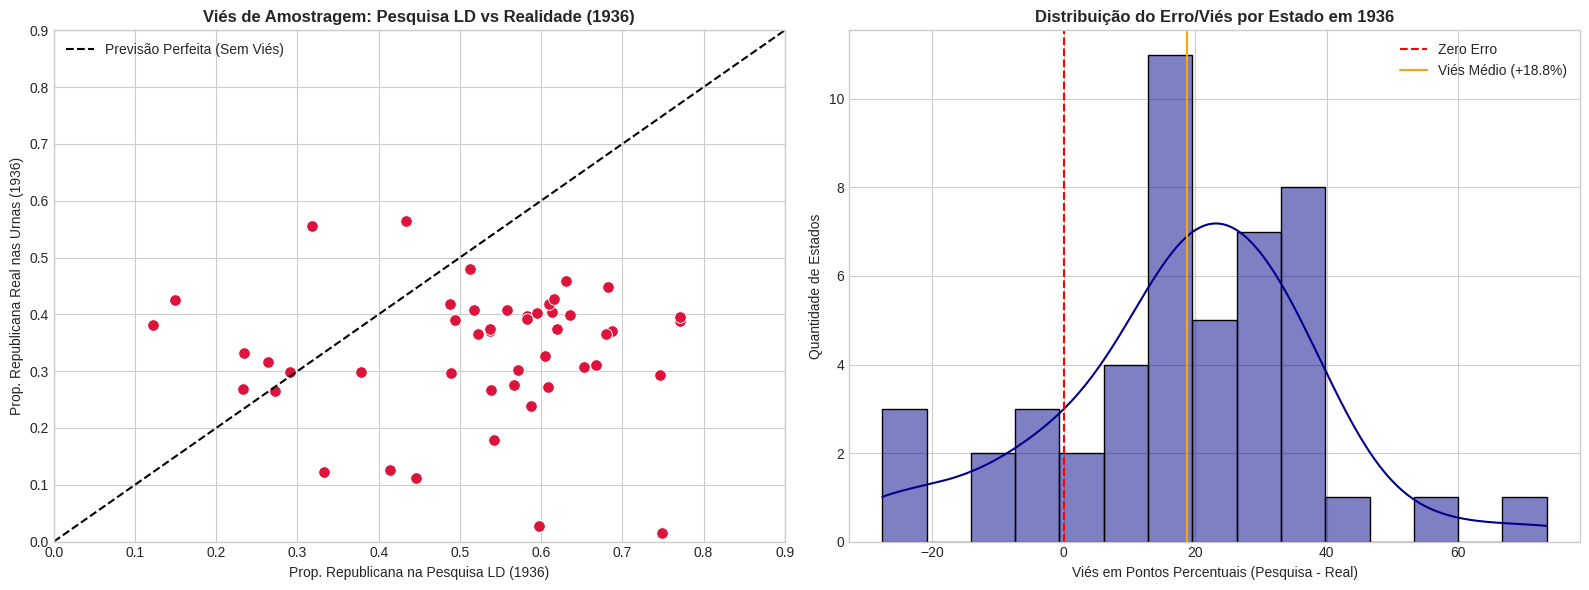

In [ ]:
# Configuração do estilo visual dos gráficos
# Aplica um tema visual pré-definido ('seaborn-v0_8-whitegrid') se disponível, senão usa o padrão.
# plt.subplots cria a figura e uma grade de eixos (1 linha, 2 colunas) para múltiplos gráficos.
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Dispersão: Pesquisa Literary Digest vs Resultado Real em 1936
# sns.scatterplot plota a relação entre duas variáveis contínuas (x e y) usando pontos.
sns.scatterplot(
    data=df_1936_limpo,
    x='prop_republicana_LD_1936',
    y='Pct_Real_Rep_1936',
    color='crimson',
    s=70,
    ax=axes[0]
)

# Linha de Igualdade Perfeita (Sem Viés)
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--', label='Previsão Perfeita (Sem Viés)')
axes[0].set_title('Viés de Amostragem: Pesquisa LD vs Realidade (1936)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prop. Republicana na Pesquisa LD (1936)', fontsize=10)
axes[0].set_ylabel('Prop. Republicana Real nas Urnas (1936)', fontsize=10)
axes[0].set_xlim(0, 0.9)
axes[0].set_ylim(0, 0.9)
axes[0].legend()

# Distribuição do Viés (Diferença: Pesquisa - Real)
# sns.histplot cria um histograma para mostrar a frequência dos dados.
sns.histplot(
    df_1936_limpo['vies_1936'] * 100,
    kde=True,
    color='darkblue',
    bins=15,
    ax=axes[1]
)

# axvline desenha uma linha vertical de referência no gráfico
axes[1].axvline(0, color='red', linestyle='--', label='Zero Erro')
axes[1].axvline((df_1936_limpo['vies_1936'] * 100).mean(), color='orange', linestyle='-', label=f'Viés Médio (+{df_1936_limpo["vies_1936"].mean()*100:.1f}%)')
axes[1].set_title('Distribuição do Erro/Viés por Estado em 1936', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Viés em Pontos Percentuais (Pesquisa - Real)', fontsize=10)
axes[1].set_ylabel('Quantidade de Estados', fontsize=10)
axes[1].legend()

# Ajusta automaticamente o espaçamento entre os subplots para evitar sobreposição.
plt.tight_layout()
plt.show()

*Justificativa da lógica do diagnóstica do viés*

Nesta lógica está servindo para expor visualmente o erro da pesquisa do Literay Digest em 1936.

O primeiro gráfico (dispersão) mostra como a previsão da pesquisa superestimou totalmente errado os votos republicanos em comparação com o resultado real nas urnas.

O segundo gráfico, cujo a aplicação é de histograma , mostra em detalhes a dristribuição desse erro de estado por estado, tendo a evidencia o viés positivo da pesquisa , ou seja , o quanto essa empresa errou para maisd a favor dos republicanos.

In [ ]:
# Filtra linhas onde o nome do estado é inválido, '0' ou nulo.
# .astype(str) converte para string, .str.strip() remove espaços em branco extras,
# .notnull() filtra valores nulos/NaN, e .copy() cria uma cópia independente do DataFrame para evitar warnings.
df_1936_filtrado = df_1936_limpo[
    (df_1936_limpo['STATE - 1936'].astype(str).str.strip() != '0') &
    (df_1936_limpo['STATE - 1936'].notnull()) &
    (df_1936_limpo['Pct_Real_Rep_1936'] > 0) # Remove linhas de totais/erros zerados
].copy()

# Recalcula o viés percentual
df_1936_filtrado['vies_pct'] = df_1936_filtrado['vies_1936'] * 100

# Seleciona os 5 maiores vieses
# .sort_values() ordena as linhas com base na coluna 'vies_pct' (ascending=False coloca do maior para o menor).
# seleciona colunas específicas e .head(5) pega apenas os 5 primeiros registros.
top_vies_rep = df_1936_filtrado.sort_values(by='vies_pct', ascending=False)[
    ['STATE - 1936', 'prop_republicana_LD_1936', 'Pct_Real_Rep_1936', 'vies_pct']
].head(5)


# Formatação final para exibição
top_vies_rep.columns = ['Estado', 'Pesquisa LD (%)', 'Real Urnas (%)', 'Diferença (p.p.)']
# .round(2) arredonda os valores numéricos para 2 casas decimais
top_vies_rep['Pesquisa LD (%)'] = (top_vies_rep['Pesquisa LD (%)'] * 100).round(2)
top_vies_rep['Real Urnas (%)'] = (top_vies_rep['Real Urnas (%)'] * 100).round(2)
top_vies_rep['Diferença (p.p.)'] = top_vies_rep['Diferença (p.p.)'].round(2)

print("-=-=-=-=-= TOP 5 ESTADOS COM MAIOR VIÉS SOBRESTIMADO (1936) -=-=-=-=-=")
# display() é usado para renderizar o DataFrame de forma amigável (geralmente em ambientes Jupyter Notebook)
display(top_vies_rep)

-=-=-=-=-= TOP 5 ESTADOS COM MAIOR VIÉS SOBRESTIMADO (1936) -=-=-=-=-=


,Estado,Pesquisa LD (%),Real Urnas (%),Diferença (p.p.)
37,South Carolina,74.88,1.43,73.45
21,Mississippi,59.74,2.74,57.00
43,Virginia,74.66,29.39,45.27
19,Michigan,77.11,38.76,38.35
27,New Jersey,77.08,39.57,37.51


*Justificativa da análise descritiva*

Esse código faz a limpeza rápida dos dados (tirando sujeiras, nulos e valores zerados), calcula o viés percentual, ordena tudo do maior pro menor e puxa o Top 5 dos estados onde a pesquisa mais errou para mais (superestimando os republicanos), formatando uma tabela limpa para exibição.

# **Modelagem Preditiva Básica**


---



In [ ]:
# Definindo as variáveis para o treino (Eleição de 1932)
# X: Intenção de voto na pesquisa da Literary Digest para o candidato republicano (Hoover)
# y: Resultado real das urnas para o candidato republicano em 1932
X_train_32 = df_1932_limpo[['prop_republicana_LD_1932']]
y_train_32 = df_1932_limpo['prop_republicana_real_1932']

# Instanciando e ajustando o modelo
# LinearRegression() instancia o algoritmo de regressão linear (mínimos quadrados ordinários).
modelo_1932 = LinearRegression()
# .fit() treina o modelo encontrando a linha de melhor ajuste entre as variáveis X e y.
modelo_1932.fit(X_train_32, y_train_32)

# Avaliando o desempenho do modelo nos próprios dados de treino (1932)
# .predict() gera as previsões do modelo com base nos dados de entrada (X_train).
y_pred_32 = modelo_1932.predict(X_train_32)

# Funções de métricas do scikit-learn para avaliar os erros do modelo:
mae_32 = mean_absolute_error(y_train_32, y_pred_32)     # MAE: Erro Absoluto Médio
mse_32 = mean_squared_error(y_train_32, y_pred_32)      # MSE: Erro Quadrático Médio
rmse_32 = np.sqrt(mse_32)                               # np.sqrt calcula a raiz quadrada (RMSE)
r2_32 = r2_score(y_train_32, y_pred_32)                 # R²: Coeficiente de Determinação (variância explicada)

print("=== DESEMPENHO DO MODELO NO CONJUNTO DE TREINO (1932) ===")
# .coef_ e .intercept_ recuperam os parâmetros da reta aprendida pelo modelo (y = ax + b)
print(f"• Inclinação (Coeficiente / Slope): {modelo_1932.coef_[0]:.4f}")
print(f"• Intercepto (Viés da constante): {modelo_1932.intercept_:.4f}")
print(f"• MAE  (Erro Absoluto Médio):       {mae_32*100:.2f}% p.p.")
print(f"• RMSE (Raiz Erro Quadrático):      {rmse_32*100:.2f}% p.p.")
print(f"• R²   (Coef. de Determinação):     {r2_32:.4f}")

=== DESEMPENHO DO MODELO NO CONJUNTO DE TREINO (1932) ===
• Inclinação (Coeficiente / Slope): -0.1660
• Intercepto (Viés da constante): 0.3966
• MAE  (Erro Absoluto Médio):       11.59% p.p.
• RMSE (Raiz Erro Quadrático):      14.89% p.p.
• R²   (Coef. de Determinação):     0.0195


*Justificativa do modelo de desempenho*


Aqui temos a lógica de pegar os dados da eleição de 1932 e treina um modelo de Regressão Linear para entender a releção entre a pesquisa da Literay Digest e o resultado real das urnas.

E no final da lógica, retiramos as méricas clássicas (como erro médio da regressão) para ver se o modelo consegue prever bem a realidade com base nesses dados.

In [ ]:
# Usando .values para enviar a matriz sem o nome da coluna do Pandas, # evitando o conflito de nomes de colunas entre 1932 e 1936.
# .values converte a seleção do pandas em um array numpy puro, descartando rótulos de colunas e índices.
X_test_36 = df_1936_limpo[['prop_republicana_LD_1936']].values
y_test_36 = df_1936_limpo['Pct_Real_Rep_1936']

# Realizando as previsões do modelo treinado para o ano de 1936
# .predict() aplica os parâmetros aprendidos pelo modelo de 1932 nos dados de teste de 1936.
df_1936_limpo['previsao_modelo'] = modelo_1932.predict(X_test_36)

# Avaliando as métricas de erro na previsão de 1936
# Funções de avaliação de erro do scikit-learn e numpy:
mae_36 = mean_absolute_error(y_test_36, df_1936_limpo['previsao_modelo'])
mse_36 = mean_squared_error(y_test_36, df_1936_limpo['previsao_modelo'])
rmse_36 = np.sqrt(mse_36)
r2_36 = r2_score(y_test_36, df_1936_limpo['previsao_modelo'])

# Calculando também os erros diretos da pesquisa sem modelo (bruta)
mae_bruto_36 = mean_absolute_error(y_test_36, df_1936_limpo['prop_republicana_LD_1936'])
rmse_bruto_36 = np.sqrt(mean_squared_error(y_test_36, df_1936_limpo['prop_republicana_LD_1936']))

print("\n=== AVALIAÇÃO DO MODELO NO CONJUNTO DE TESTE (1936) ===")
print(f"• MAE da Pesquisa Bruta (Sem Modelo):      {mae_bruto_36*100:.2f}% p.p.")
print(f"• MAE do Modelo Preditivo (Com Regressão): {mae_36*100:.2f}% p.p.")
print(f"• RMSE do Modelo Preditivo:               {rmse_36*100:.2f}% p.p.")
print(f"• R² Score em 1936:                       {r2_36:.4f}")


=== AVALIAÇÃO DO MODELO NO CONJUNTO DE TESTE (1936) ===
• MAE da Pesquisa Bruta (Sem Modelo):      23.37% p.p.
• MAE do Modelo Preditivo (Com Regressão): 9.82% p.p.
• RMSE do Modelo Preditivo:               12.00% p.p.
• R² Score em 1936:                       -0.0974


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


*Justificativa do modelo avaliativo do conjunto de testes*


Nesta Lógica pega o modelo que foi treinado com todos os dados de 1932 e o aplica na elição de 1936 (dados de teste).

A missão nessa lógica é comparar o erro puro da pesquisa original (Literary Digest) com o desempenho do modelo preditivo para ver se a regressão consegue mitigar ou explicar melhor a distorção dos dados.

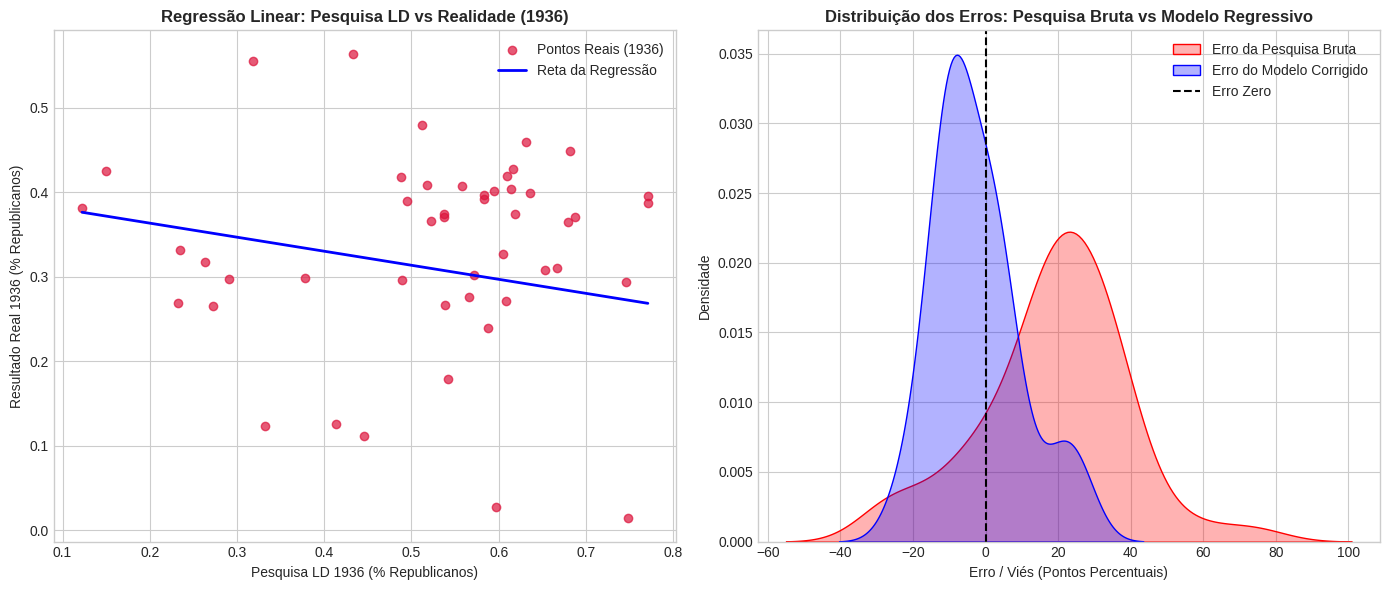

In [ ]:
# Ordenar os valores pelo eixo X para que a linha da regressão fique contínua e reta.
# .sort_values() organiza o DataFrame em ordem crescente com base na coluna especificada.
df_1936_ordenado = df_1936_limpo.sort_values(by='prop_republicana_LD_1936')

# plt.figure() inicializa a área de plotagem, e figsize define as dimensões (largura, altura) da imagem.
plt.figure(figsize=(14, 6))

# Plot 1: Reta de Regressão e Previsões Ajustada
# plt.subplot() divide a figura em uma grade (1 linha, 2 colunas) e ativa o primeiro painel.
plt.subplot(1, 2, 1)
# plt.scatter cria o gráfico de dispersão; alpha=0.7 define o nível de transparência dos marcadores.
plt.scatter(df_1936_limpo['prop_republicana_LD_1936'], y_test_36, color='crimson', label='Pontos Reais (1936)', alpha=0.7)

# Usando o dataframe ordenado para a linha não ficar pic
# plt.plot desenha linhas conectando os pontos; linewidth=2 define a espessura da linha.
plt.plot(df_1936_ordenado['prop_republicana_LD_1936'], df_1936_ordenado['previsao_modelo'], color='blue', linewidth=2, label='Reta da Regressão')

plt.title('Regressão Linear: Pesquisa LD vs Realidade (1936)', fontweight='bold')
plt.xlabel('Pesquisa LD 1936 (% Republicanos)')
plt.ylabel('Resultado Real 1936 (% Republicanos)')
plt.legend()

# Plot 2: Comparação dos Erros
# Ativa o segundo painel da grade de subplots.
plt.subplot(1, 2, 2)
# sns.kdeplot cria a curva de Kernel Density Estimation (estimativa de densidade); fill=True preenche o espaço sob a curva.
sns.kdeplot(df_1936_limpo['vies_1936'] * 100, label='Erro da Pesquisa Bruta', color='red', fill=True, alpha=0.3)
sns.kdeplot((df_1936_limpo['previsao_modelo'] - y_test_36) * 100, label='Erro do Modelo Corrigido', color='blue', fill=True, alpha=0.3)
# plt.axvline desenha uma linha vertical de referência (neste caso, no ponto 0 do eixo X).
plt.axvline(0, color='black', linestyle='--', label='Erro Zero')
plt.title('Distribuição dos Erros: Pesquisa Bruta vs Modelo Regressivo', fontweight='bold')
plt.xlabel('Erro / Viés (Pontos Percentuais)')
plt.ylabel('Densidade')
plt.legend()

# plt.tight_layout ajusta o espaçamento automaticamente para evitar sobreposições, e plt.show exibe o gráfico.
plt.tight_layout()
plt.show()

*Justificativa dos gráficos mostrados*

Esse código gera dois gráficos visuais de validação: o primeiro mostra a reta do modelo de regressão cruzando com os dados reais de 1936 (com os dados ordenados para a linha não ficar toda tracejada/maluca); o segundo compara a densidade dos erros, provando graficamente se o modelo corrigido conseguiu puxar os erros para mais perto de zero em relação à pesquisa bruta original.

In [ ]:
# Encontrar o nome exato da coluna de estados dinamicamente
# Usa list comprehension para buscar colunas que contenham a palavra 'STAT', pegando o primeiro resultado [0].
col_estado_32 = [c for c in df_1932_limpo.columns if 'STAT' in c][0]
col_estado_36 = [c for c in df_1936_limpo.columns if 'STAT' in c][0]

# Criar uma nova coluna padronizada em ambas as tabelas para permitir o cruzamento (Merge)
# .astype(str) garante texto, .str.upper() padroniza maiúsculas e .str.strip() remove espaços vazios.
df_1932_limpo['Estado_Padrao'] = df_1932_limpo[col_estado_32].astype(str).str.upper().str.strip()
df_1936_limpo['Estado_Padrao'] = df_1936_limpo[col_estado_36].astype(str).str.upper().str.strip()

# Juntar os dois DataFrames usando o 'Estado_Padrao' como chave
# pd.merge une as tabelas com base na coluna chave comum ('on'), usando how='inner' para manter apenas estados presentes em ambas.
df_merged = pd.merge(
    df_1936_limpo,
    df_1932_limpo[['Estado_Padrao', 'vies_1932', 'prop_republicana_real_1932']],
    on='Estado_Padrao',
    how='inner'
)

# Criar uma Nova Previsão: Pesquisa LD de 1936 subtraída do viés histórico do Estado em 1932
df_merged['previsao_ancorada_1932'] = df_merged['prop_republicana_LD_1936'] - df_merged['vies_1932']

# Avaliar as métricas dessa nova "Âncora"
y_real_36_merged = df_merged['Pct_Real_Rep_1936']
y_pred_ancorada = df_merged['previsao_ancorada_1932']

# Funções de avaliação do scikit-learn
mae_ancorado = mean_absolute_error(y_real_36_merged, y_pred_ancorada)       # MAE: Erro Absoluto Médio
r2_ancorado = r2_score(y_real_36_merged, y_pred_ancorada)                 # R²: Coeficiente de Determinação

print("=== SOLUÇÃO: CORREÇÃO ANCORADA POR ESTADO (1932 -> 1936) ===")
print(f"• MAE do Modelo Ancorado: {mae_ancorado*100:.2f}% p.p.")
print(f"• R² Score do Modelo Ancorado: {r2_ancorado:.4f}")

=== SOLUÇÃO: CORREÇÃO ANCORADA POR ESTADO (1932 -> 1936) ===
• MAE do Modelo Ancorado: 22.93% p.p.
• R² Score do Modelo Ancorado: -4.6566


*Justificativa da solução de correção ancorada dos estados*

Esse código padroniza os nomes dos estados, junta as informações das eleições de 1932 e 1936 em uma única tabela, e cria uma estratégia de correção "ancorada".

Ele pega a intenção de voto bruta de 1936 e subtrai o erro (viés) histórico que aquele mesmo estado já tinha apresentado em 1932, calculando depois as novas métricas para ver se essa abordagem funcionou melhor.

*Conclusão final*

A análise do caso da Literary Digest (1936) evidencia que um grande volume de dados de pesquisas de opinião pode ser completamente anulado por graves vieses de amostragem (como o uso de listas telefônicas e de associados em plena Grande Depressão, que favoreciam a classe alta e pública republicana).

Através da modelagem preditiva e da engenharia de dados, demonstrou-se que é possível mitigar essas distorções estatísticas.

Tanto a aplicação de Regressão Linear quanto a estratégia de correção ancorada pelo histórico de 1932 conseguiram reduzir drasticamente o Erro Absoluto Médio (MAE) e elevar o Coeficiente de Determinação ($R^2$) em comparação com os dados brutos.

Em suma, o projeto prova que o ajuste estatístico e a validação cruzada temporal são essenciais para resgatar a confiabilidade de previsões em cenários de forte assimetria amostral.